In [ ]:
# !unzip FMD_Cattle.zip

In [1]:
!pip install roboflow

In [2]:
import os
import glob

In [3]:
# Main Path
dataset_path = 'FMD_Cattle'

# Search jpg~ files
search_pattern = os.path.join(dataset_path, '**', '*.jpg~')
files_to_rename = glob.glob(search_pattern, recursive=True)
print(list(files_to_rename))

[]


In [28]:
# Rename the files
if not files_to_rename:
  pass
else:
  count = 0
  for old_path in files_to_rename:
    new_path = old_path.rstrip('~')
    os.rename(old_path, new_path)
    count += 1
  print(f"{count} images formatted successfully")

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [6]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    # shear_range=0.2,
    # zoom_range=0.1,
    horizontal_flip=True,
    # vertical_flip=True,
    cval=0.0,
    fill_mode='nearest'
)

val_gen = ImageDataGenerator(
    rescale=1./255,
    # rotation_range=20,
    # width_shift_range=0.2,
    # height_shift_range=0.2,
    # shear_range=0.2,
    # zoom_range=0.1,
    # horizontal_flip=True,
    # vertical_flip=True,
    # fill_mode='nearest'
)

In [15]:
from pathlib import Path

IMG_SIZE = (500, 500)
BATCH = 16

train_ds = train_gen.flow_from_directory(
    Path(dataset_path) / 'train',
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='binary',
    shuffle=True
)

val_ds = val_gen.flow_from_directory(
    Path(dataset_path) / 'val',
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='binary',
    shuffle=True
)

Found 251 images belonging to 2 classes.
Found 40 images belonging to 2 classes.


In [7]:
print(f'Train Batches: {len(train_ds)}')
print(f'Val Batches: {len(val_ds)}')

Train Batches: 16
Val Batches: 3


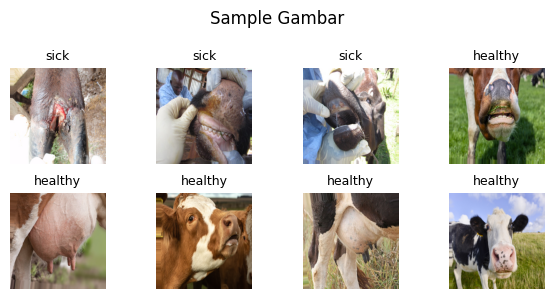

In [18]:
import matplotlib.pyplot as plt
import numpy as np

def show_random_images(images_data):
  # Reset the generator to ensure it starts from the beginning of an epoch.
  # This is crucial because `len(images_data)` (e.g., in `print(f'Val Batches: {len(val_ds)}')`)
  # exhausts the generator's current epoch. Resetting ensures a full batch for display.
  images_data.reset()

  batch_imags, batch_labels = next(iter(images_data))

  # Get class names from the generator's class_indices attribute
  class_names = list(images_data.class_indices.keys())

  fig, axes = plt.subplots(2, 4, figsize=(6, 3))
  for i, ax in enumerate(axes.flat):
    ax.imshow(batch_imags[i])
    # Correctly map binary label to class name. class_mode='binary' means labels are 0 or 1.
    # Direct indexing with the integer label is the correct approach.
    ax.set_title(class_names[int(batch_labels[i])], fontsize=9)
    ax.axis('off')
  plt.suptitle("Sample Gambar", fontsize=12)
  plt.tight_layout()
  plt.show()

show_random_images(train_ds)

## Create The Model

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np

### Helper Functions

In [10]:
def plot_history(history):
  fig, axes = plt.subplots(1, 2, figsize=(10, 4))

  axes[0].plot(history.history['accuracy'], label='Train Acc', color='royalblue')
  axes[0].plot(history.history['val_accuracy'], label='Val Acc', color='tomato')
  axes[0].set_title('Accuracy per Epoch')
  axes[0].set_xlabel('Epoch')
  axes[0].set_ylabel('Accuracy')
  axes[0].legend()
  axes[0].grid(True)

  axes[1].plot(history.history['loss'], label='Train Loss', color='royalblue')
  axes[1].plot(history.history['val_loss'], label='Val Loss', color='tomato')
  axes[1].set_title('Loss per Epoch')
  axes[1].set_xlabel('Epoch')
  axes[1].set_ylabel('Loss')
  axes[1].legend()
  axes[1].grid(True)

  plt.tight_layout()
  plt.savefig('/content/training_history.png', dpi=150)
  plt.show()

In [15]:
cb_list = [
    # callbacks.ModelCheckpoint(
    #     filepath='/content/best_model.keras',
    #     monitor='val_accuracy',
    #     save_best_only=True,
    #     verbose=1
    # ),
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1 # Corrected typo 'verbode' to 'verbose'
    )
]

### Base Model

In [53]:
num_classes = len(train_ds.class_indices)

def build_cnn(input_shape=(500, 500, 3), num_classes=2):
  model = models.Sequential([
      layers.Conv2D(256, (3, 3), activation='relu', input_shape=input_shape),
      layers.MaxPooling2D(2, 2),

      layers.Conv2D(256, (3, 3), activation='relu'),
      layers.MaxPooling2D(2, 2),

      layers.Conv2D(128, (3, 3), activation='relu'),
      layers.MaxPooling2D(2, 2),

      layers.Conv2D(64, (3, 3), activation='relu'),
      layers.MaxPooling2D(2, 2),

      layers.Conv2D(32, (3, 3), activation='relu'),
      layers.MaxPooling2D(2, 2),

      layers.BatchNormalization(momentum=0.9),

      layers.Conv2D(16, (3, 3), activation='relu'),
      layers.MaxPooling2D(2, 2),

      layers.Flatten(),

      layers.Dense(128, activation='relu'),
      layers.Dropout(0.2),
      layers.Dense(64, activation='relu'),
      layers.Dropout(0.2),

      layers.Dense(1, activation='sigmoid') # Changed to 1 output neuron with sigmoid

  ])

  return model

base_model = build_cnn(num_classes=num_classes) # num_classes is still 2, but the build_cnn function has a default of 2 and will now override it with 1
base_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 498, 498, 256)  │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 249, 249, 256)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 247, 247, 256)  │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 123, 123, 256)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 121, 121, 128)  │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 60, 60, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 58, 58, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 27, 27, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 13, 13, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 11, 11, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        51,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,048,945 (4.00 MB)

 Trainable params: 1,048,881 (4.00 MB)

 Non-trainable params: 64 (256.00 B)

In [54]:
base_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='binary_crossentropy', # Changed to binary_crossentropy
    metrics=['accuracy']
)

base_history = base_model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds, # Temporarily commented out due to previous image loading issues
    # callbacks=cb_list
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 112s 4s/step - accuracy: 0.5578 - loss: 0.7448 - val_accuracy: 0.6250 - val_loss: 0.7230
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 888ms/step - accuracy: 0.6096 - loss: 0.6457 - val_accuracy: 0.6750 - val_loss: 0.6712
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 910ms/step - accuracy: 0.6693 - loss: 0.6210 - val_accuracy: 0.6000 - val_loss: 0.6477
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 949ms/step - accuracy: 0.6892 - loss: 0.5860 - val_accuracy: 0.7250 - val_loss: 0.6178
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 887ms/step - accuracy: 0.6972 - loss: 0.5868 - val_accuracy: 0.6750 - val_loss: 0.7665
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 869ms/step - accuracy: 0.6892 - loss: 0.5719 - val_accuracy: 0.6500 - val_loss: 0.7351
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 890ms/step - accuracy: 0.7092 - loss: 0.5539 - val_accuracy: 0.6750 - val_loss: 0.5938
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 916ms/step - accuracy: 0.7171 - loss: 0.5403 - val_accura

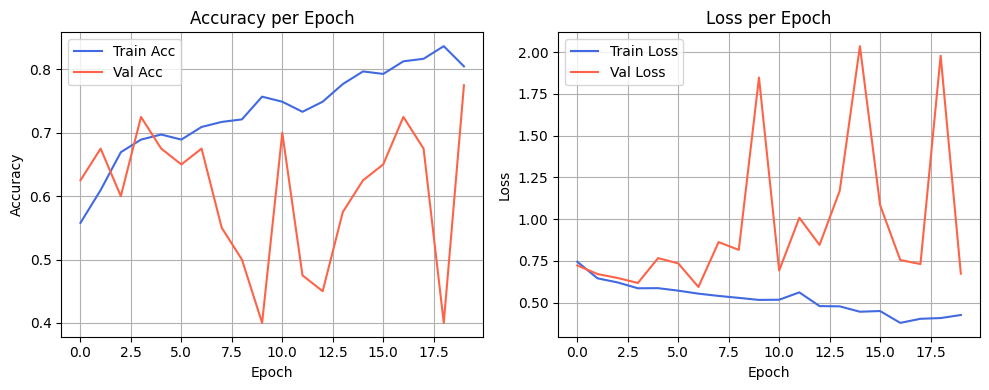

In [55]:
plot_history(base_history)

In [24]:
from tensorflow.keras.preprocessing import image
import numpy as np

In [51]:
classes = ['healthy', 'sick']

img_path = 'test-2-s.jpg'
img = tf.keras.preprocessing.image.load_img(path=img_path, target_size=(500, 500))

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

predictions = base_model.predict(img_array)
score = predictions[0]

predicted_class_index = int(np.round(score))
predicted_class_name = classes[predicted_class_index]

print(predicted_class_name)
print(score)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
healthy
[0.37342158]


/tmp/ipykernel_720/3640038310.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predicted_class_index = int(np.round(score))


## Change Dataset

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="API_KEY")
project = rf.workspace("operating-room").project("cows-mien3")
version = project.version(1)
dataset = version.download("folder")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Cows-1 in folder:: 100%|██████████| 2986/2986 [00:00<00:00, 6195.82it/s]


### Delete 'Lumpy Skin' folders
This code will remove the 'Lumpy Skin' subdirectories from your 'train', 'test', and 'valid' folders within the `Cows-1` directory. Be cautious, as this action is irreversible.

In [3]:
import shutil
import os

base_dir = 'Cows-1'
subdirs_to_check = ['train', 'test', 'valid']
target_class_folder = 'Lumpy Skin'

print(f"Attempting to remove '{target_class_folder}' folders from: {base_dir}")

for subdir in subdirs_to_check:
    folder_path = os.path.join(base_dir, subdir, target_class_folder)
    if os.path.exists(folder_path):
        print(f"Deleting: {folder_path}")
        shutil.rmtree(folder_path)
        print(f"Successfully deleted: {folder_path}")
    else:
        print(f"Folder not found, skipping: {folder_path}")

print("Deletion process complete.")

Attempting to remove 'Lumpy Skin' folders from: Cows-1
Deleting: Cows-1/train/Lumpy Skin
Successfully deleted: Cows-1/train/Lumpy Skin
Deleting: Cows-1/test/Lumpy Skin
Successfully deleted: Cows-1/test/Lumpy Skin
Deleting: Cows-1/valid/Lumpy Skin
Successfully deleted: Cows-1/valid/Lumpy Skin
Deletion process complete.


In [17]:
from pathlib import Path

DATASET_PATH_V2 = 'Cows-1'
IMG_SIZE = (224, 224) # Reduced image size
BATCH = 16 # Reduced batch size

train_ds = train_gen.flow_from_directory(
    Path(DATASET_PATH_V2) / 'train',
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='binary',
    shuffle=True
)

val_ds = val_gen.flow_from_directory(
    Path(DATASET_PATH_V2) / 'valid',
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='binary',
    shuffle=True
)

test_ds = val_gen.flow_from_directory(
    Path(DATASET_PATH_V2) / 'test',
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='binary',
    shuffle=True
)

Found 1986 images belonging to 2 classes.
Found 186 images belonging to 2 classes.
Found 97 images belonging to 2 classes.


In [18]:
print(f'Train Batches: {len(train_ds)}')
print(f'Valid Batches: {len(val_ds)}')
print(f'Test Batches: {len(test_ds)}')

Train Batches: 125
Valid Batches: 12
Test Batches: 7


In [19]:
num_classes = len(train_ds.class_indices)

def build_cnn(input_shape=(224, 224, 3), num_classes=2): # Updated input_shape
  model = models.Sequential([
      layers.Conv2D(256, (3, 3), activation='relu', input_shape=input_shape),
      layers.MaxPooling2D(2, 2),

      layers.Conv2D(256, (3, 3), activation='relu'),
      layers.MaxPooling2D(2, 2),

      layers.Conv2D(128, (3, 3), activation='relu'),
      layers.MaxPooling2D(2, 2),

      layers.Conv2D(64, (3, 3), activation='relu'),
      layers.MaxPooling2D(2, 2),

      layers.Conv2D(32, (3, 3), activation='relu'),
      layers.MaxPooling2D(2, 2),

      layers.BatchNormalization(momentum=0.9),

      layers.Conv2D(16, (3, 3), activation='relu'),
      layers.MaxPooling2D(2, 2),

      layers.Flatten(),

      layers.Dense(128, activation='relu'),
      layers.Dropout(0.2),
      layers.Dense(64, activation='relu'),
      layers.Dropout(0.2),

      layers.Dense(1, activation='sigmoid') # Changed to 1 output neuron with sigmoid

  ])

  return model

second_model = build_cnn(num_classes=num_classes) # num_classes is still 2, but the build_cnn function has a default of 2 and will now override it with 1
second_model.summary()

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 256)  │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 256)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 256)  │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 24, 24, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 10, 10, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5, 5, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 3, 3, 16)       │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 1, 1, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 999,793 (3.81 MB)

 Trainable params: 999,729 (3.81 MB)

 Non-trainable params: 64 (256.00 B)

In [20]:
second_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='binary_crossentropy', # Changed to binary_crossentropy
    metrics=['accuracy']
)

second_history = second_model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=cb_list
)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 54s 303ms/step - accuracy: 0.6571 - loss: 0.6368 - val_accuracy: 0.6613 - val_loss: 0.6305 - learning_rate: 0.0010
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 25s 199ms/step - accuracy: 0.6667 - loss: 0.6246 - val_accuracy: 0.6613 - val_loss: 1.2517 - learning_rate: 0.0010
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 24s 192ms/step - accuracy: 0.6697 - loss: 0.6180 - val_accuracy: 0.6559 - val_loss: 0.6109 - learning_rate: 0.0010
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 24s 194ms/step - accuracy: 0.6928 - loss: 0.6041 - val_accuracy: 0.6828 - val_loss: 0.5770 - learning_rate: 0.0010
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 24s 189ms/step - accuracy: 0.6994 - loss: 0.5862 - val_accuracy: 0.7366 - val_loss: 0.5284 - learning_rate: 0.0010
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 24s 190ms/step - accuracy: 0.7175 - loss: 0.5445 - val_accuracy: 0.6613 - val_loss: 1.0465 - learning_rate: 0.0010
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 24s 191ms/step - accuracy: 0.7

In [21]:
second_model.evaluate(test_ds, verbose=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 253ms/step - accuracy: 0.9278 - loss: 0.1967


[0.19670911133289337, 0.9278350472450256]

## Inference

In [22]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import os
import shutil

In [25]:
TARGET_UPLOAD_FOLDER = 'uploaded_images'
if not os.path.exists(TARGET_UPLOAD_FOLDER):
  os.makedirs(TARGET_UPLOAD_FOLDER)
  print(f"folder '{TARGET_UPLOAD_FOLDER}' created")

class_names = ['fmd', 'normal'] # Ensure these match your actual class labels

def predict_result(model):
  uploaded_image = files.upload()

  for filename in uploaded_image.keys():
    # Move uploaded file to 'uploaded_images' folder
    source_path = filename
    destination_path = os.path.join(TARGET_UPLOAD_FOLDER, filename)

    shutil.move(source_path, destination_path)

    # Load image with proper size
    img_width, img_height = 224, 224
    img = tf.keras.preprocessing.image.load_img(path=destination_path, target_size=(img_width, img_height))

    # Preprocess image with rescaling
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0) # change shape to (1, 224, 224, 3)

    # Predicting
    predictions = model.predict(img_array)
    # For binary classification, predictions[0] will be a single value (e.g., [0.7])
    probability = predictions[0][0] # Get the scalar probability

    # Determine predicted class and confidence
    if probability >= 0.5:
        predicted_class_name = class_names[1] # 'normal' is assumed to be the positive class (index 1)
        confidence = probability * 100
    else:
        predicted_class_name = class_names[0] # 'fmd' is assumed to be the negative class (index 0)
        confidence = (1 - probability) * 100

    # Show image and prediction result
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"prediction: {predicted_class_name}\nconfidence: {confidence:.2f}%")
    plt.axis('off')
    plt.show()

Saving Diseased foot 10.jpg to Diseased foot 10.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


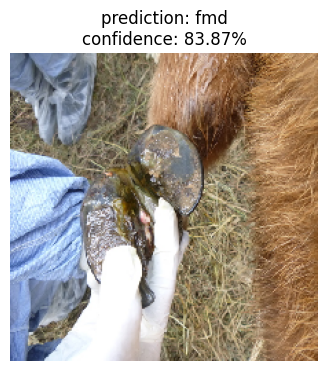

In [27]:
predict_result(second_model)

In [ ]:
second_model.save()

In [28]:
second_model.save('fmd_cnn_best_model.h5')